In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_ROOT = "split_dataset"

train_ds = image_dataset_from_directory(
    f"C:\\Users\\sthar\\abcd\\techsprint_xhack\\ml-app\\split_dataset\\train",
    labels="inferred",
    label_mode="binary",
    class_names=["Au", "Tp"],   # IMPORTANT
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    f"C:\\Users\\sthar\\abcd\\techsprint_xhack\\ml-app\\split_dataset\\val",
    labels="inferred",
    label_mode="binary",
    class_names=["Au", "Tp"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    f"C:\\Users\\sthar\\abcd\\techsprint_xhack\\ml-app\\split_dataset\\test",
    labels="inferred",
    label_mode="binary",
    class_names=["Au", "Tp"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 2419 files belonging to 2 classes.
Found 318 files belonging to 2 classes.
Found 661 files belonging to 2 classes.


In [3]:
from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


In [4]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Phase 1

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
model.summary()

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.5345 - auc: 0.5403 - loss: 0.8356 - val_accuracy: 0.5377 - val_auc: 0.5730 - val_loss: 0.7291
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.5883 - auc: 0.6202 - loss: 0.7083 - val_accuracy: 0.5912 - val_auc: 0.6138 - val_loss: 0.7023
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.6036 - auc: 0.6446 - loss: 0.6833 - val_accuracy: 0.6258 - val_auc: 0.6160 - val_loss: 0.7008
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6494 - auc: 0.7042 - loss: 0.6292 - val_accuracy: 0.5975 - val_auc: 0.6317 - val_loss: 0.6919
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.6722 - auc: 0.7365 - loss: 0.6054 - val_accuracy: 0.6164 - val_auc: 0.6355 - val_loss: 0.6908
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6937 - auc: 0.7581 - loss: 0.5840 - val_accuracy: 0.6352 - val_auc: 0.6488 - val_loss: 0.6842
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,162,117 (95.99 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,049,604 (4.00 MB)

In [7]:
test_loss, test_acc, test_auc = model.evaluate(test_ds)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test AUC      : {test_auc:.4f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6082 - auc: 0.6602 - loss: 0.6660
Test Accuracy : 0.6082
Test AUC      : 0.6602


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


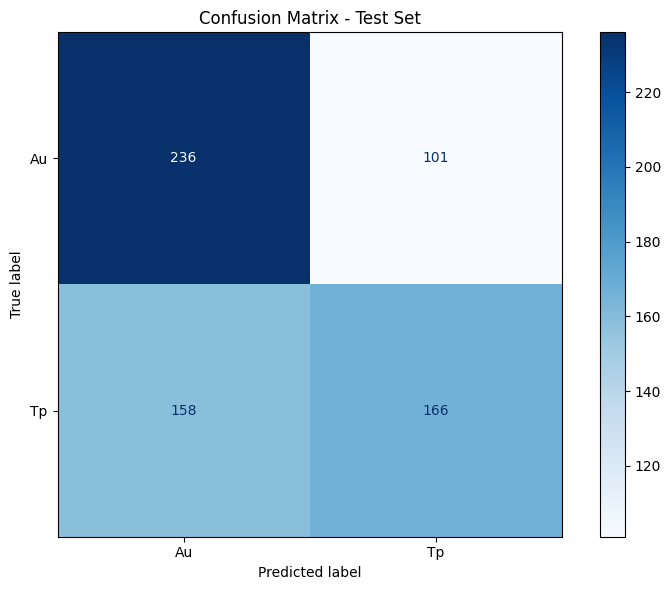


Classification Report:
              precision    recall  f1-score   support

          Au       0.60      0.70      0.65       337
          Tp       0.62      0.51      0.56       324

    accuracy                           0.61       661
   macro avg       0.61      0.61      0.60       661
weighted avg       0.61      0.61      0.60       661


Confusion Matrix Breakdown:
True Negatives (TN):  236
False Positives (FP): 101
False Negatives (FN): 158
True Positives (TP):  166

Sensitivity (Recall): 0.5123
Specificity: 0.7003
Precision: 0.6217


In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions from test dataset
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Au", "Tp"])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Au", "Tp"]))

# Print detailed metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print(f"\nSensitivity (Recall): {tp / (tp + fn):.4f}")
print(f"Specificity: {tn / (tn + fp):.4f}")
print(f"Precision: {tp / (tp + fp):.4f}" if (tp + fp) > 0 else "Precision: N/A")